In [ ]:
from pathlib import Path
import datasets as hf_datasets

ROOT = Path(".").resolve().parent

BUILTIN_DATASETS = {
    "agievalar-dev":   "datasets/agievalar/dev.parquet",
    "agievalar-test":  "datasets/agievalar/test.parquet",
    "aqua-train":      "datasets/aqua/train.parquet",
    "aqua-test":       "datasets/aqua/test.parquet",
    "aqua-validation": "datasets/aqua/validation.parquet",
    "arc-train":       "datasets/arc/arc_train.parquet",
    "arc-test":        "datasets/arc/arc_test.parquet",
    "arc-validation":  "datasets/arc/arc_validation.parquet",
    "gsm8k-train":     "datasets/gsm8k/train.parquet",
    "gsm8k-test":      "datasets/gsm8k/test.parquet",
    "mmlu-test":       "datasets/mmlu/test.parquet",
    "mmlu-validation": "datasets/mmlu/validation.parquet",
}

print(f"{'Dataset':<22} {'Total':>8}")
print("-" * 32)
for alias, rel_path in BUILTIN_DATASETS.items():
    full_path = ROOT / rel_path
    if full_path.exists():
        ds = hf_datasets.Dataset.from_parquet(str(full_path))
        print(f"{alias:<22} {len(ds):>8}")
    else:
        print(f"{alias:<22} {'N/A':>8}")


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

ROOT = Path(".").resolve().parent
sys.path.insert(0, str(ROOT))

In [ ]:
def load_results(results_dir: Path) -> dict:
    """Le todos os JSONs de um diretório e retorna {dataset: accuracy}."""
    data = {}
    for json_file in sorted(results_dir.glob("*.json")):
        with open(json_file, encoding="utf-8") as f:
            summary = json.load(f)["summary"]
        data[summary["dataset"]] = summary["accuracy"]
    return data


# Dados reais: phi
phi_dir = ROOT / "results" / "phi" / "all_tests"
llama_dir = ROOT / "results" / "llama3.1_8b" / "all_tests"

phi_results = load_results(phi_dir)
llama_results = load_results(llama_dir)

print("phi   :", phi_results)
print("llama :", llama_results)

phi   : {'agievalar-test': 0.23, 'aqua-test': 0.3, 'arc-test': 0.7, 'gsm8k-test': 0.16, 'mmlu-test': 0.18}
llama : {'agievalar-test': 0.18, 'aqua-test': 0.58, 'arc-test': 0.8, 'gsm8k-test': 0.9, 'mmlu-test': 0.54}


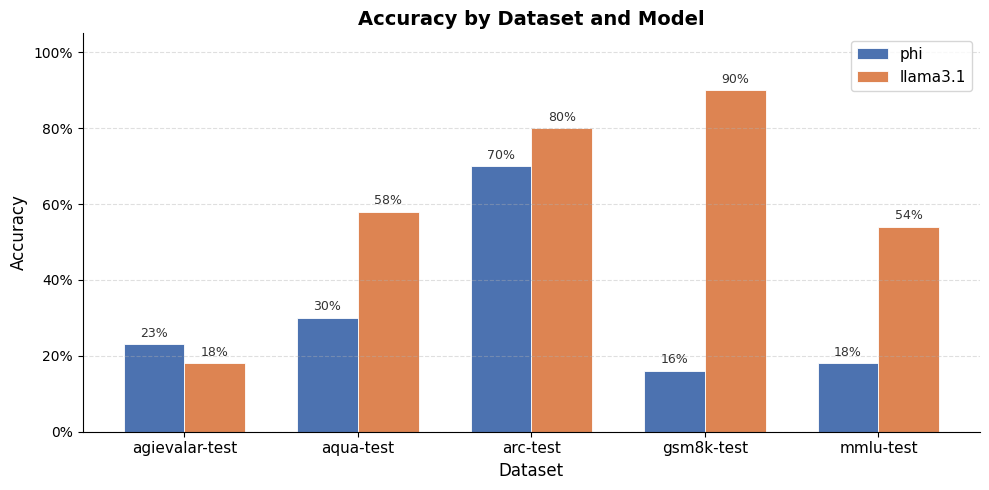

In [4]:
datasets = sorted(set(phi_results) | set(llama_results))

models = {
    "phi":             phi_results,
    "llama3.1": llama_results,
}

n_models  = len(models)
bar_width = 0.35
x         = np.arange(len(datasets))
colors    = ["#4C72B0", "#DD8452"]

fig, ax = plt.subplots(figsize=(10, 5))

for i, (model_name, results) in enumerate(models.items()):
    offsets    = x + (i - (n_models - 1) / 2) * bar_width
    accuracies = [results.get(d, 0.0) for d in datasets]
    bars = ax.bar(
        offsets, accuracies,
        width=bar_width,
        label=model_name,
        color=colors[i],
        edgecolor="white",
        linewidth=0.6,
    )
    for bar, acc in zip(bars, accuracies):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f"{acc:.0%}",
            ha="center", va="bottom",
            fontsize=9, color="#333333",
        )

ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.05)
ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Accuracy by Dataset and Model", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(ROOT / "plots" / "accuracy_by_dataset.png", dpi=150)
plt.show()